In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Mall_Customers.csv")

print(df.head())
print(df.shape)

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)


In [2]:
print(df.isnull().sum())
print(df.describe())

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


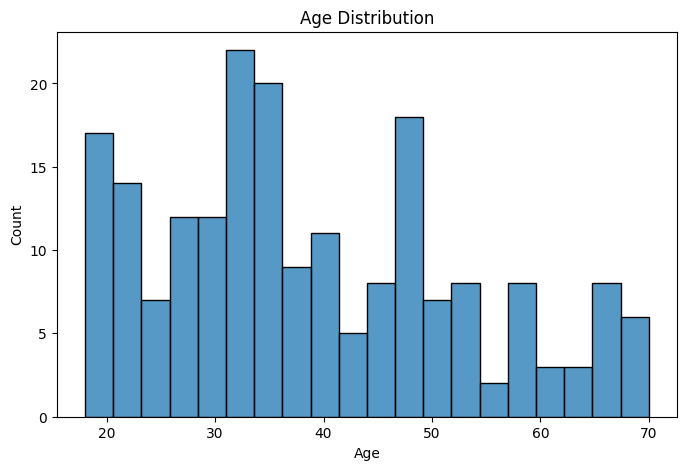

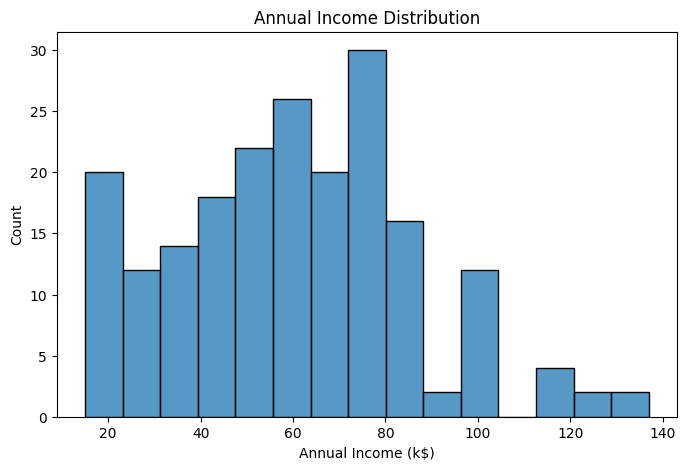

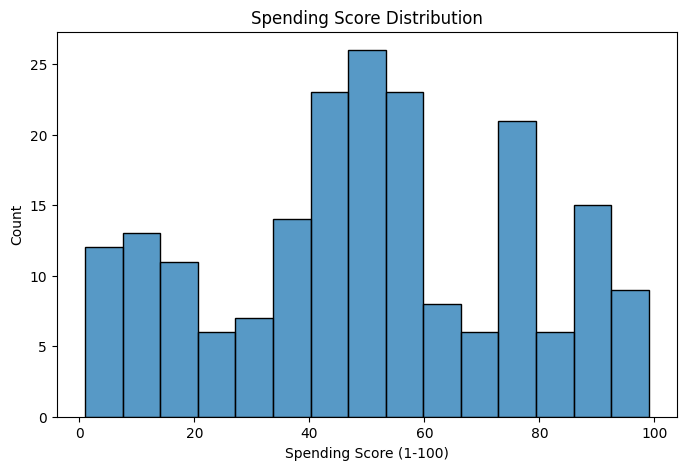

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.title('Age Distribution')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=15)
plt.title('Annual Income Distribution')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Spending Score (1-100)'], bins=15)
plt.title('Spending Score Distribution')
plt.show()

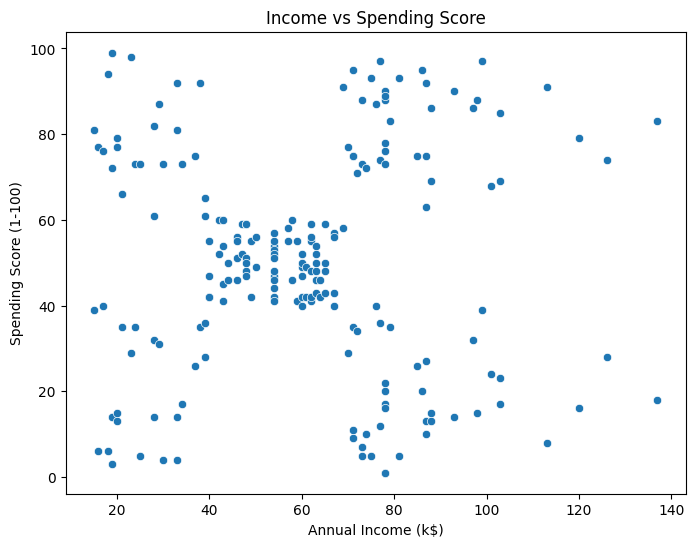

In [4]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title('Income vs Spending Score')
plt.show()

In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


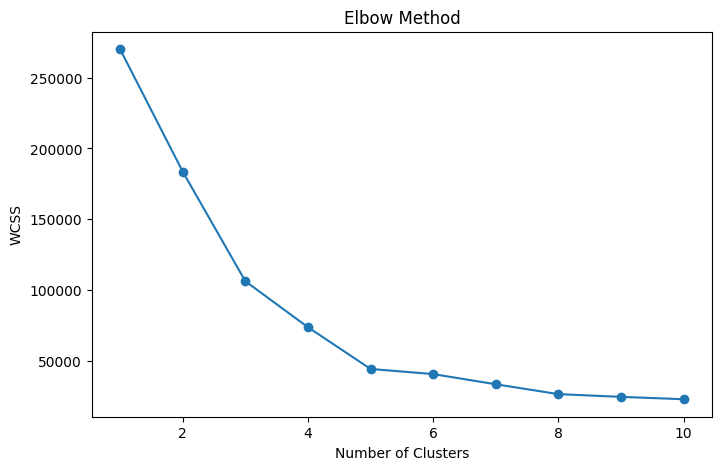

<Figure size 640x480 with 0 Axes>

In [18]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )
    
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()
plt.savefig('Elbow_method.png')

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

In [8]:
df['Cluster'] = y_kmeans
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [9]:
print(df['Cluster'].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


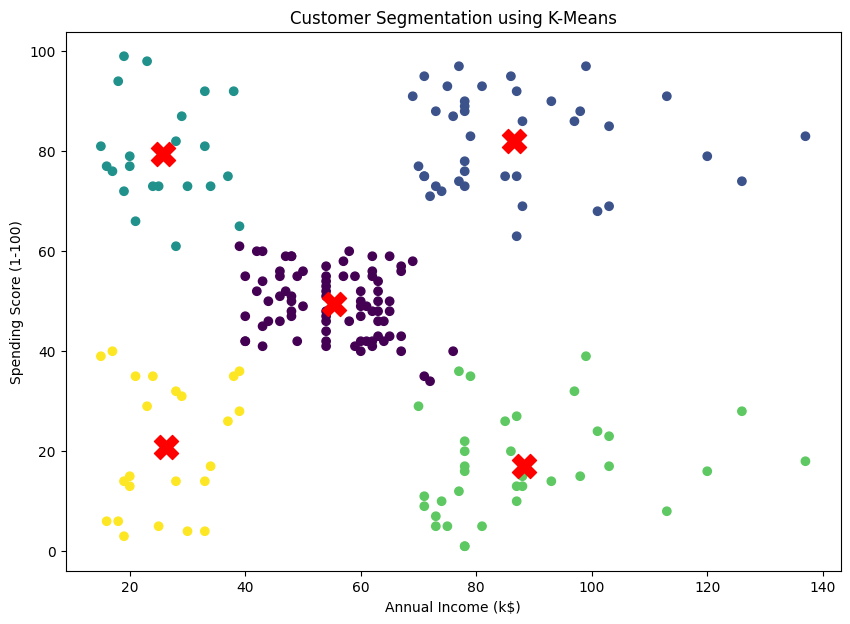

<Figure size 640x480 with 0 Axes>

In [17]:
plt.figure(figsize=(10,7))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y_kmeans,
    cmap='viridis'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='red',
    marker='X'
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()
plt.savefig('Customer_Clusters.png')

In [11]:
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)','Spending Score (1-100)','Age']].mean()

print(cluster_summary)

         Annual Income (k$)  Spending Score (1-100)        Age
Cluster                                                       
0                 55.296296               49.518519  42.716049
1                 86.538462               82.128205  32.692308
2                 25.727273               79.363636  25.272727
3                 88.200000               17.114286  41.114286
4                 26.304348               20.913043  45.217391


In [12]:
print(df['Cluster'].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [13]:
segment_names = {
    0: 'Average Customers',
    1: 'Premium Customers',
    2: 'Potential Loyalists',
    3: 'Careful Customers',
    4: 'Budget Customers'
}

df['Segment'] = df['Cluster'].map(segment_names)
print(df[['Cluster','Segment']].head())

   Cluster              Segment
0        4     Budget Customers
1        2  Potential Loyalists
2        4     Budget Customers
3        2  Potential Loyalists
4        4     Budget Customers


In [14]:
print(df['Segment'].value_counts())

Segment
Average Customers      81
Premium Customers      39
Careful Customers      35
Budget Customers       23
Potential Loyalists    22
Name: count, dtype: int64


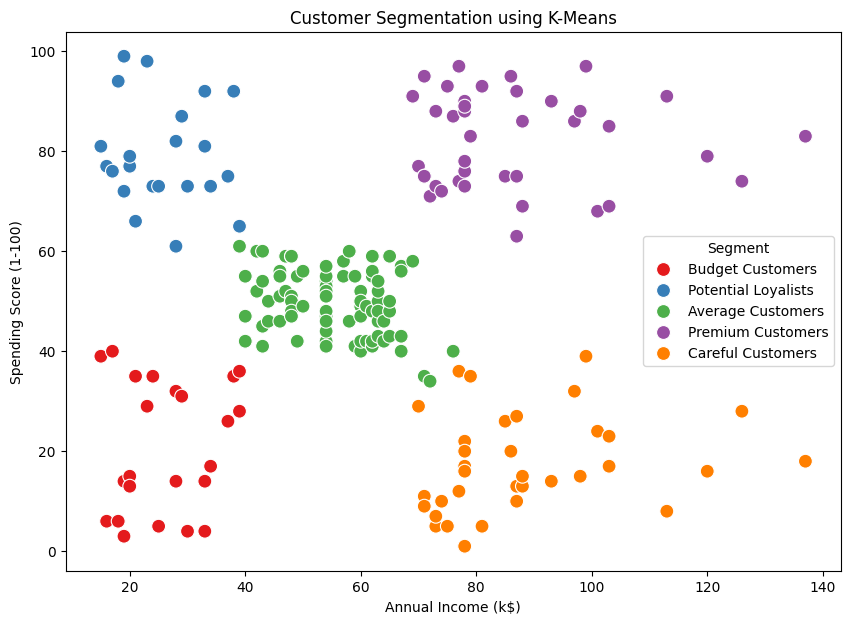

In [15]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Segment',
    palette='Set1',
    s=100
)

plt.title('Customer Segmentation using K-Means')
plt.savefig('Customer_Clusters.png')
plt.show()

In [16]:
df.to_csv('Customer_Segmentation_Result.csv', index=False)